# LeetCode #461: Hamming Distance

https://leetcode.com/problems/hamming-distance/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (compare bit by bit)** | $O(1)$ — 32 iters | $O(1)$ |
| **Optimal: XOR + Popcount ★** | $O(1)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (compare bit by bit)
Loop 32 times, compare each bit of x and y individually with a shifting mask, count differences. Correct but verbose.

### Optimal: XOR + Popcount ★
XOR produces a number whose set bits are exactly the positions where x and y differ. Count those set bits with the built-in popcount instruction — one XOR, one popcount, done.

**Why this is better than Brute Force:** Two operations instead of 32 iterations; popcount is a single CPU instruction on modern hardware.

**Constraints:**
* $0 \le x, y \le 2^{31} - 1$

## Solutions

### C#

In [ ]:
using System.Numerics;

public int HammingDistance(int x, int y) {
    // XOR marks differing bit positions; popcount counts them
    return BitOperations.PopCount((uint)(x ^ y));
}

### Python

In [ ]:
def hammingDistance(self, x: int, y: int) -> int:
    # XOR marks differing bit positions; count set bits in result
    return bin(x ^ y).count('1')

### Go

In [ ]:
import "math/bits"

func hammingDistance(x int, y int) int {
    // XOR marks differing bit positions; popcount counts them
    return bits.OnesCount(uint(x ^ y))
}

### Rust

In [ ]:
pub fn hamming_distance(x: i32, y: i32) -> i32 {
    // XOR marks differing bit positions; popcount counts them
    (x ^ y).count_ones() as i32
}

## Example Scenarios

**1. Common Case**
**Input:** x=1 (001), y=4 (100)
XOR = 001⊕100 = 101. popcount(101) = **2** (bits 0 and 2 differ).

**2. Slightly Complex**
**Input:** x=93 (1011101), y=73 (1001001)
XOR = 1011101⊕1001001 = 0010100. popcount = **2** (bits 2 and 4 differ). Seven-bit numbers but only two positions differ.

**3. Edge Case: Time Factor**
**Input:** x=0, y=2147483647 ($2^{31}-1$, all lower 31 bits set)
XOR = 2147483647. popcount = 31. Single XOR + single popcount = $O(1)$ regardless of how many bits differ.

**4. Edge Case: Space Factor**
**Input:** x=2147483647, y=2147483647 (same max value)
XOR = 0. popcount(0) = 0. Return **0** — zero differing bits. No auxiliary data structure; constant $O(1)$ space.

**5. Almost-Impossible but Plausible**
**Input:** x=2147483647 ($2^{31}-1$), y=0
XOR = 2147483647. popcount = 31. All 31 lower bits differ. Tests the maximum possible Hamming distance for 32-bit signed inputs (the sign bit at position 31 is 0 in both, so at most 31 differ).

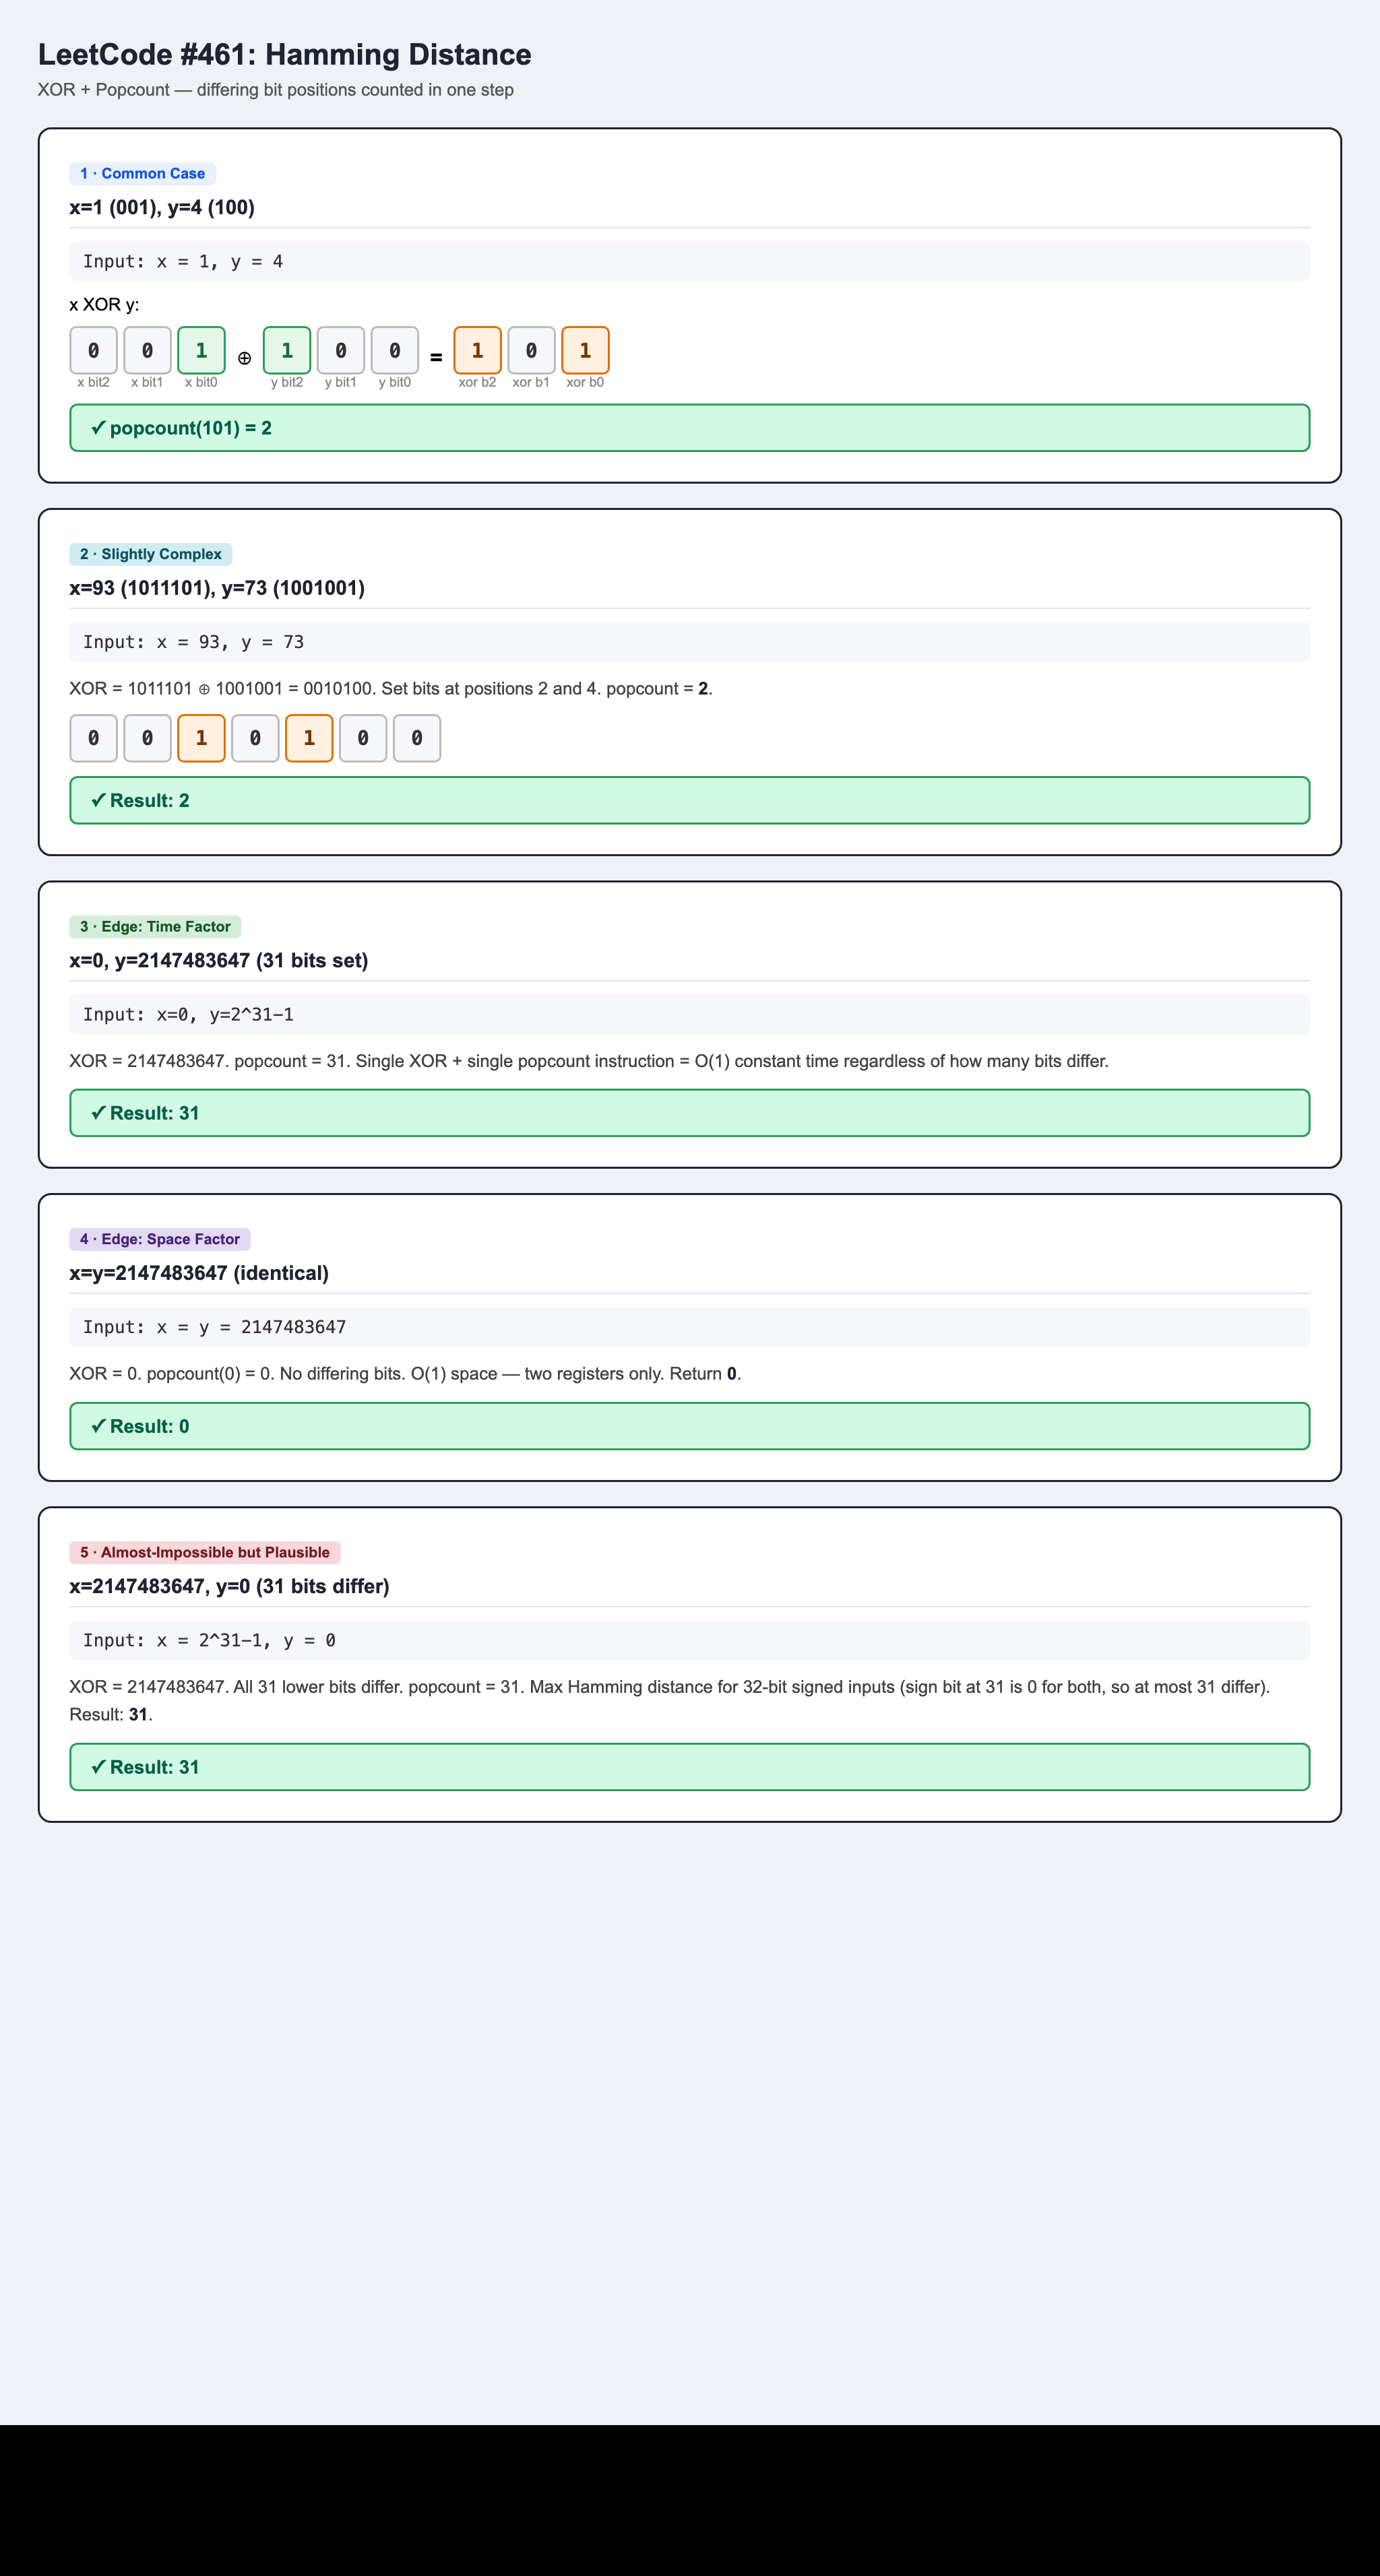